# 13_核方法-Sigmoid核

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 大规模参数网格缩为每维至多两个候选值；所有候选仍真实训练，未跳过运行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们今天来聊聊Sigmoid核\~

#### 首先，核方法是什么？

在实验中，有些数据的特征之间关系是非线性的，也就是说，无法直接用一条直线或平面将不同类别的数据分开。核方法是一种技巧，核心思想是：

**将数据从原来的空间“映射”到一个更高维的空间，在高维空间中可能就可以用简单的方法（比如线性分类器）来解决问题。**

但是，直接把数据“搬”到高维空间代价很大。于是，核方法通过**核函数**，在不显式进行高维映射的前提下，**计算两个数据点在高维空间中的内积（相似度）**。这样就可以节省计算资源，又达到提升模型能力的目的。

#### 那么，什么是核函数？

核函数是一种**用来衡量两个数据点相似程度的函数**。它相当于“帮你在高维空间中做了计算”，但你其实并不用真的去那个空间操作。

常见的核函数有：

- 线性核
- 多项式核
- 高斯核（RBF）
- Sigmoid 核（本节重点）

其实，Sigmoid 很好理解，大家可以把 Sigmoid 核理解为：

**先看两个样本有多像（点积），再进行一些线性调整（乘上 α，加上 c），最后通过 S 形函数压缩结果，得到一个非线性的相似度。**

这种方法很像早期神经网络中的一个“神经元”的计算方式，所以 Sigmoid 核也叫**神经元核**。

总结一句话，Sigmoid 核函数就是通过一个 S 形函数，模拟神经元的行为，把线性相似度转换成非线性形式，用于核方法中提升模型处理复杂数据的能力。

## 原理详解

核方法的核心思想在于：

> 在原始空间中无法线性可分的数据，通过一个非线性映射函数 $\phi(x)$，映射到一个更高维的特征空间中，使其变得线性可分。

即：


$$
x \mapsto \phi(x) \in \mathcal{H}
$$


其中 $\mathcal{H}$ 是高维或无限维的希尔伯特空间。在该空间中，分类问题可以通过线性模型进行处理。

由于显式计算 $\phi(x)$ 很昂贵甚至不可能，核方法使用**核函数** $K(x, x')$ 来间接计算：


$$
K(x, x') = \langle \phi(x), \phi(x') \rangle_{\mathcal{H}}
$$


### Sigmoid 核定义

Sigmoid 核（双曲正切核）的形式如下：


$$
K(x, x') = \tanh(\alpha \cdot x^T x' + c)
$$


其中：

- $x, x' \in \mathbb{R}^d$ 是输入向量
- $x^T x'$ 表示内积，衡量两点的相似性
- $\alpha > 0$ 是缩放因子（scale）
- $c \in \mathbb{R}$ 是偏移项（bias）
- $\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$ 是双曲正切函数

## 数学推理

### 1. 来源于神经网络的激活函数

Sigmoid 核函数的形式与单层前馈神经网络中的激活函数完全一致。设想一个感知器神经元模型：


$$
y = \tanh(w^T x + b)
$$


如果我们用神经网络思想来表示核函数，那么可以理解为：


$$
K(x, x') = \tanh(\alpha \cdot x^T x' + c)
$$


即将输入向量 $x$ 与另一个输入 $x'$ 的内积代入感知器中，并以 $\tanh$ 激活。

这个形式与经典的神经网络中“加权求和 + 激活函数”的单元结构完全一致。

### 2. 是否满足 Mercer 定理？

一个函数 $K(x, x')$ 是否能作为核函数，必须满足 **Mercer 定理**，即在输入空间中必须对应某个隐式的特征空间 $\phi(x)$，使得：


$$
K(x, x') = \langle \phi(x), \phi(x') \rangle
$$


Sigmoid 核并不总是满足 Mercer 条件，仅在某些参数范围下（如适当的 $\alpha$ 和 $c$ 值）才满足。因此它并不如高斯核那样普适，使用时需要注意正定性。

### 特征空间中的隐式映射理解

虽然我们不能显式写出对应的映射 $\phi(x)$，但 Sigmoid 核函数其实**隐含了一个非线性变换**，使得模型可以在非线性空间中进行线性学习。

我们可以理解为：虽然我们不知道 $\phi(x)$ 是什么，但核函数已经帮我们“跳过”这个步骤，直接做了在高维空间中的相似度计算。

---

### 算法流程（以支持向量机 SVM 为例）

下面是将 Sigmoid 核用于支持向量机（SVM）时的算法流程：

#### 步骤 1：准备数据

输入数据集 $\{(x_i, y_i)\}_{i=1}^n$，其中：

$x_i \in \mathbb{R}^d$：输入特征

$y_i \in \{-1, +1\}$：标签

#### 步骤 2：选定核函数

使用 Sigmoid 核函数：


$$
K(x_i, x_j) = \tanh(\alpha \cdot x_i^T x_j + c)
$$


#### 步骤 3：构造对偶问题

SVM 的原始优化问题是：


$$
\min_{w, b, \xi} \ \frac{1}{2} \|w\|^2 + C \sum_i \xi_i \quad \text{s.t. } y_i(w^T \phi(x_i) + b) \geq 1 - \xi_i, \ \xi_i \geq 0
$$


使用拉格朗日乘子法转化为对偶问题：


$$
\max_{\alpha} \sum_{i=1}^{n} \alpha_i - \frac{1}{2} \sum_{i,j=1}^{n} \alpha_i \alpha_j y_i y_j K(x_i, x_j) \quad \text{s.t. } 0 \leq \alpha_i \leq C, \ \sum_i \alpha_i y_i = 0
$$


其中核函数 $K(x_i, x_j)$ 用的是 Sigmoid 核。

#### 步骤 4：求解拉格朗日对偶问题

使用某种二次规划算法（如 SMO）来优化 $\alpha$，求解得到支持向量。

#### 步骤 5：构建决策函数

最终的分类器形式为：


$$
f(x) = \text{sign}\left( \sum_{i=1}^{n} \alpha_i y_i \cdot K(x_i, x) + b \right)
$$


即每个支持向量 $x_i$ 都通过核函数 $K(x_i, x)$ 来对新样本 $x$ 施加影响。

### 参数选择对性能的影响

Sigmoid 核中的参数 $\alpha$ 和 $c$ 对模型影响很大：

- 若 $\alpha$ 太大或太小，会导致函数过度压缩或扩展，影响模型非线性表达能力

$c$ 控制了函数的偏移，会影响输出的平衡性

实际应用中通常使用交叉验证等方法选择最优参数。

## 完整案例

咱们这里，给大家整体介绍如何使用支持向量机（SVM）中的**Sigmoid核函数**来解决非线性分类问题。

包括数据生成、训练、调参、评估和结果可视化的完整流程。

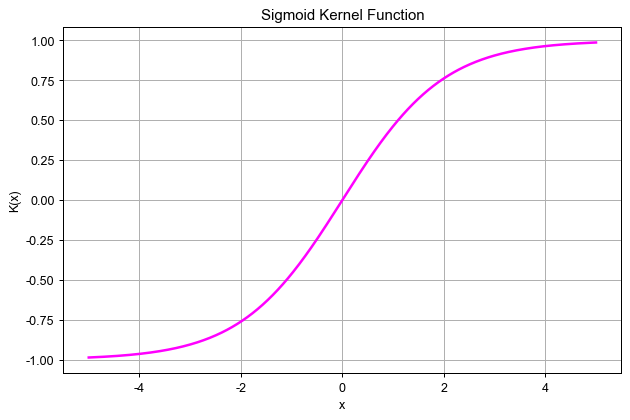

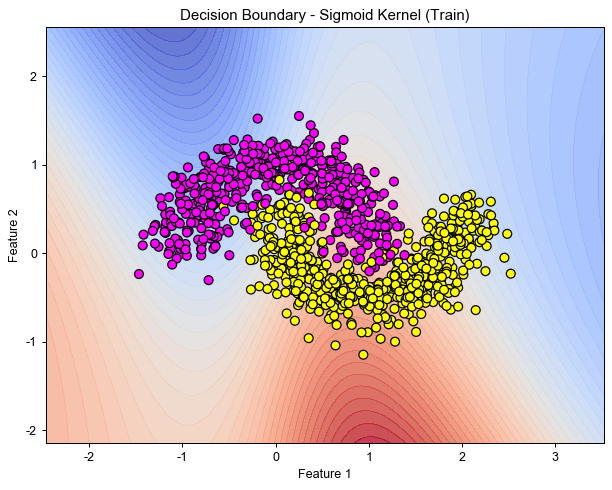

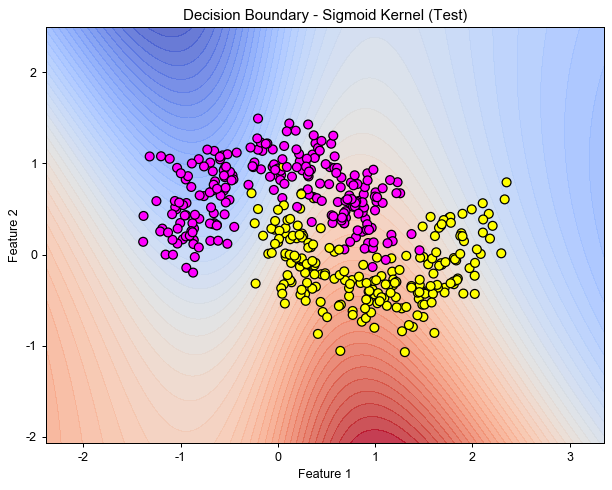

Accuracy (Sigmoid Kernel): 0.7

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.66      0.70       234
           1       0.67      0.75      0.70       216

    accuracy                           0.70       450
   macro avg       0.70      0.70      0.70       450
weighted avg       0.70      0.70      0.70       450



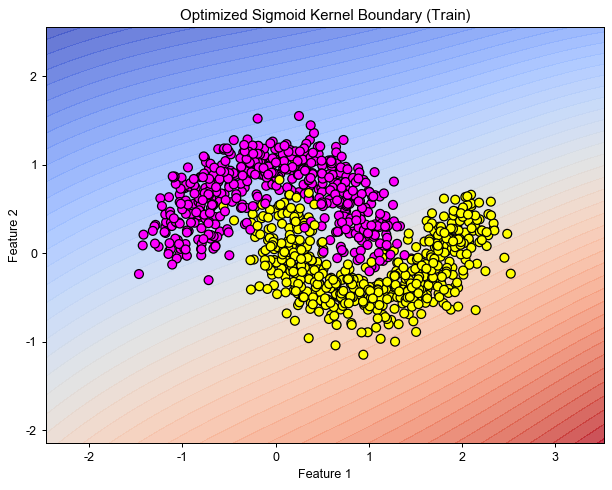

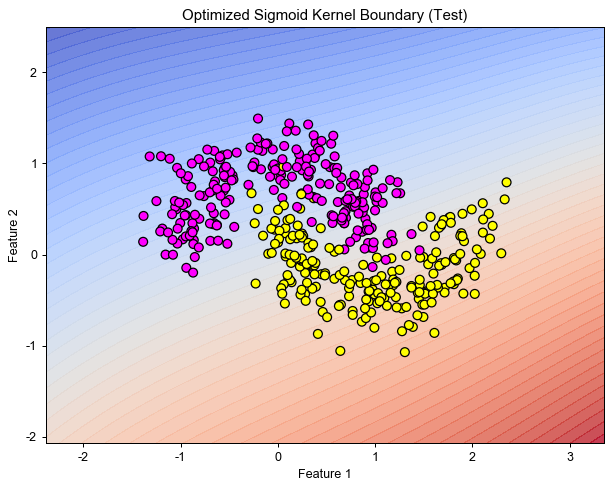

Optimized Parameters: {'C': 1, 'coef0': -1, 'gamma': 0.1}
Optimized Accuracy: 0.8866666666666667

Optimized Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.89       234
           1       0.90      0.86      0.88       216

    accuracy                           0.89       450
   macro avg       0.89      0.89      0.89       450
weighted avg       0.89      0.89      0.89       450



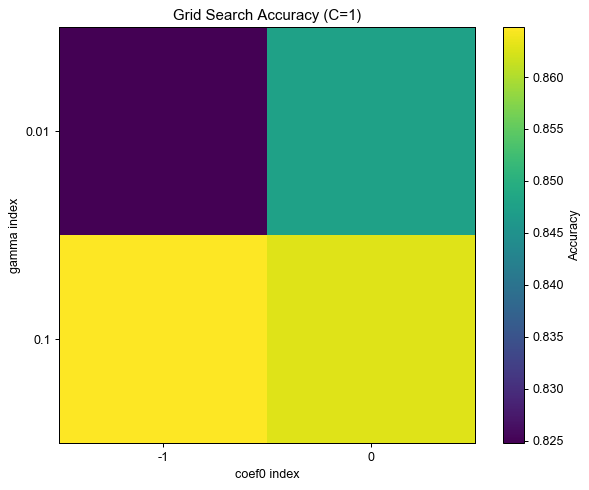

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, accuracy_score
import warnings


# 1. 生成数据集
# 使用 make_moons 生成非线性可分的二分类数据
X, y = make_moons(n_samples=1500, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. 定义 Sigmoid 核函数
def sigmoid_kernel(x, y, gamma=0.1, coef0=0.0):
    """Sigmoid Kernel: tanh(gamma <x, y> + coef0)"""
    return np.tanh(gamma * np.dot(x, y.T) + coef0)

# 可视化 Sigmoid 核函数
x_vals = np.linspace(-5, 5, 500)
K_vals = np.tanh(0.5 * x_vals + 0.0)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, K_vals, linestyle='-', linewidth=2, color='magenta')
plt.title('Sigmoid Kernel Function')
plt.xlabel('x')
plt.ylabel('K(x)')
plt.grid(True)
plt.show()

# 3. 使用 Sigmoid 核训练 SVM
svm_sigmoid = SVC(kernel='sigmoid', gamma=0.5, coef0=0.0)
svm_sigmoid.fit(X_train, y_train)

# 4. 可视化决策边界
def plot_decision_boundary(model, X, y, title):
    xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 500),
                         np.linspace(X[:,1].min()-1, X[:,1].max()+1, 500))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, levels=50, cmap=plt.cm.coolwarm, alpha=0.8)
    plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.spring, edgecolors='k', s=50)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

plot_decision_boundary(svm_sigmoid, X_train, y_train, 'Decision Boundary - Sigmoid Kernel (Train)')
plot_decision_boundary(svm_sigmoid, X_test, y_test, 'Decision Boundary - Sigmoid Kernel (Test)')

# 5. 性能评估
y_pred = svm_sigmoid.predict(X_test)
print("Accuracy (Sigmoid Kernel):", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 6. 超参数优化
param_grid = {
    'gamma': [0.01, 0.1],
    'coef0': [-1, 0],
    'C': [0.1, 1]
}
grid_search = GridSearchCV(SVC(kernel='sigmoid'), param_grid, cv=5, scoring='accuracy', error_score='raise')
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_

# 7. 使用最佳参数重新训练并可视化
svm_opt = SVC(kernel='sigmoid', **best_params)
svm_opt.fit(X_train, y_train)

plot_decision_boundary(svm_opt, X_train, y_train, 'Optimized Sigmoid Kernel Boundary (Train)')
plot_decision_boundary(svm_opt, X_test, y_test, 'Optimized Sigmoid Kernel Boundary (Test)')

y_pred_opt = svm_opt.predict(X_test)
print("Optimized Parameters:", best_params)
print("Optimized Accuracy:", accuracy_score(y_test, y_pred_opt))
print("\nOptimized Classification Report:\n", classification_report(y_test, y_pred_opt))

# 8. 可视化超参数搜索结果（热图）
scores = grid_search.cv_results_['mean_test_score'].reshape(len(param_grid['gamma']),
                                                            len(param_grid['coef0']),
                                                            len(param_grid['C']))

# 选择 C=1 平面来可视化
scores_C1 = scores[:,:,param_grid['C'].index(1)]

plt.figure(figsize=(8, 6))
plt.imshow(scores_C1, interpolation='nearest', cmap='viridis')
plt.title('Grid Search Accuracy (C=1)')
plt.xlabel('coef0 index')
plt.ylabel('gamma index')
plt.colorbar(label='Accuracy')
plt.xticks(np.arange(len(param_grid['coef0'])), param_grid['coef0'])
plt.yticks(np.arange(len(param_grid['gamma'])), param_grid['gamma'])
plt.show()

#### 1. 生成数据集

使用 `make_moons` 函数生成了一个带有噪声的非线性可分的二分类数据集（1500个样本）。然后将数据按7:3的比例划分为训练集和测试集。

#### 2. 定义 Sigmoid 核函数及可视化

自定义了Sigmoid核函数的数学表达式：


$$
K(x, y) = \tanh(\gamma \langle x, y \rangle + \text{coef0})
$$


并对其在一定范围内的函数曲线进行了可视化，帮助理解Sigmoid核的形状和特性。

![原文参考图，当前结果见代码输出](attachments/img_022.png)

#### 3. 使用 Sigmoid 核训练 SVM

利用 `scikit-learn` 的 `SVC` 类，指定内核为`sigmoid`，并设置初始超参数 `gamma=0.5`，`coef0=0.0`，在训练集上训练SVM模型。

#### 4. 可视化决策边界

定义了一个函数，通过网格采样输入空间，利用训练好的模型计算决策函数值，并用等高线图和散点图结合，绘制训练集和测试集上的决策边界，直观展示模型如何划分数据。

![原文参考图，当前结果见代码输出](attachments/img_023.png)

![原文参考图，当前结果见代码输出](attachments/img_024.png)

#### 5. 性能评估

使用测试集对模型进行预测，计算并输出准确率和详细的分类报告（精确率、召回率、F1分数等），评估模型效果。

#### 6. 超参数优化

使用`GridSearchCV`对Sigmoid核的关键超参数 `gamma`, `coef0`, 和惩罚参数 `C` 进行网格搜索，基于交叉验证准确率寻找最佳组合，以提高模型性能。

#### 7. 使用最佳参数重新训练并可视化

用调参得到的最优超参数重新训练SVM，绘制新的训练和测试决策边界，观察调参后模型表现的变化。并输出新的准确率和分类报告。

#### 8. 可视化超参数搜索结果

将调参过程中不同 `gamma` 和 `coef0` 组合在 `C=1` 条件下的平均准确率以热图形式可视化，便于直观比较不同参数组合的效果。

![原文参考图，当前结果见代码输出](attachments/img_025.png)

## 模型分析

### Sigmoid核优缺点

**优点：**

- Sigmoid核函数来源于神经网络中的激活函数（tanh），在某些问题上可以模拟类似神经网络的非线性决策边界，具有一定的表达能力。
- 在某些特殊数据结构下，Sigmoid核可以表现出不同于RBF或多项式核的分类效果。
- 参数较少（主要是 `gamma` 和 `coef0`），调节后可以适应不同数据。

**缺点：**

- Sigmoid核不是正定核（非严格Mercer核），在某些情况下可能导致优化问题不收敛或者结果不稳定。
- 其性能和稳定性通常不如RBF核和多项式核，尤其在常见的非线性问题中表现较差。
- 对超参数较为敏感，需要仔细调参，否则容易欠拟合或过拟合。
- 应用范围相对较窄，且较少作为首选核函数。

### 不同核函数性能对比

| 核函数类型 | 优点 | 缺点 | 适用场景 |
|-|-|-|-|
| 线性核 | 计算简单，适合线性可分或高维稀疏数据 | 不能处理非线性问题 | 文本分类，高维稀疏数据 |
| 多项式核 | 能捕捉多项式非线性关系，参数调节灵活 | 计算复杂度高，容易过拟合 | 特征交互关系明显，数据具有多项式性质 |
| RBF核（高斯核） | 表达能力强，适用范围广，性能稳定 | 超参数选择敏感，计算资源需求较高 | 大多数非线性分类任务，广泛应用 |
| Sigmoid核 | 与神经网络激活函数类似，某些特定数据表现良好 | 非正定核，优化不稳定，性能不如RBF核 | 神经网络模型相关背景数据，实验性探索 |

### 何时优选Sigmoid核，何时考虑其他算法？

**优选Sigmoid核的情况**：如果你的数据具有类似神经网络中的非线性关系，或者你想尝试具有“神经网络激活”风格的核函数时，可以尝试Sigmoid核。另外，在资源有限且模型简单的情况下，尝试Sigmoid核进行快速实验也可以。

**考虑其他算法的情况**：

- 当你面对广泛的非线性问题时，RBF核通常是首选，因为它的表现更稳定且泛化能力强。
- 数据维度极高且线性可分时，使用线性核效率更高。
- 数据中存在显著多项式关系时，多项式核能更好地捕捉这种结构。
- 如果你需要更灵活或更强的表达能力，可以考虑深度学习模型或核方法以外的非线性模型。

综上，Sigmoid核在实践中更多是作为探索性核函数存在，并不是大多数任务的默认优选。除非有特殊需求或数据特征，否则RBF核更为稳妥，线性核和多项式核则根据数据特性选择使用。